In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Загружаем стандартизированный датасет
df = pd.read_csv('dataset_standardized.csv')

# 2. Создаем бинарную целевую переменную y
# Класс 1 (Хиты): popularity > 70
# Класс 0 (Остальные): popularity <= 70
df['Target'] = np.where(df['popularity'] > 70, 1, 0)

# 3. Формируем матрицу признаков X
# Обязательно удаляем 'popularity', иначе модель будет давать 100% точность
# Также удаляем текстовые колонки, если они вдруг остались
cols_to_drop =['popularity', 'Target', 'track_id', 'artists', 'album_name', 'track_name']
X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['Target']

# 4. Разбиваем на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Данные для бинарной классификации готовы!")
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Баланс классов в датасете:")
print(y.value_counts())
print(f"Доля хитов (класс 1): {y.mean():.2%}")

Данные для бинарной классификации готовы!
Размер обучающей выборки: (90839, 29)
Баланс классов в датасете:
Target
0    108706
1      4843
Name: count, dtype: int64
Доля хитов (класс 1): 4.27%


Обучение LogisticRegression...


C:\Users\Danya\Desktop\MAD\UNI_MAD\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Danya\Desktop\MAD\UNI_MAD\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Danya\Desktop\MAD\UNI_MAD\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 

Обучение LinearSVC...
Обучение Perceptron...

Итоговая таблица метрик:


,Алгоритм,Конфигурация,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,LogReg,"C=1.0, penalty=l2",0.957332,0.000000,0.000000,0.000000,0.747482
1,LogReg,"C=0.1, penalty=l2",0.957332,0.000000,0.000000,0.000000,0.747450
2,LogReg,"C=1.0, penalty=None",0.957332,0.000000,0.000000,0.000000,0.747502
3,LogReg,"C=0.1, penalty=None",0.957332,0.000000,0.000000,0.000000,0.747502
4,SVC,"C=1.0, loss=hinge",0.957332,0.000000,0.000000,0.000000,0.509046
5,SVC,"C=1.0, loss=squared_hinge",0.957332,0.000000,0.000000,0.000000,0.743790
6,SVC,"C=0.1, loss=hinge",0.957332,0.000000,0.000000,0.000000,0.498101
7,SVC,"C=0.1, loss=squared_hinge",0.957332,0.000000,0.000000,0.000000,0.743784
8,Perceptron,"penalty=None, alpha=0.0001",0.951915,0.103226,0.016512,0.028470,0.692871
9,Perceptron,"penalty=None, alpha=0.001",0.951915,0.103226,0.016512,0.028470,0.692871


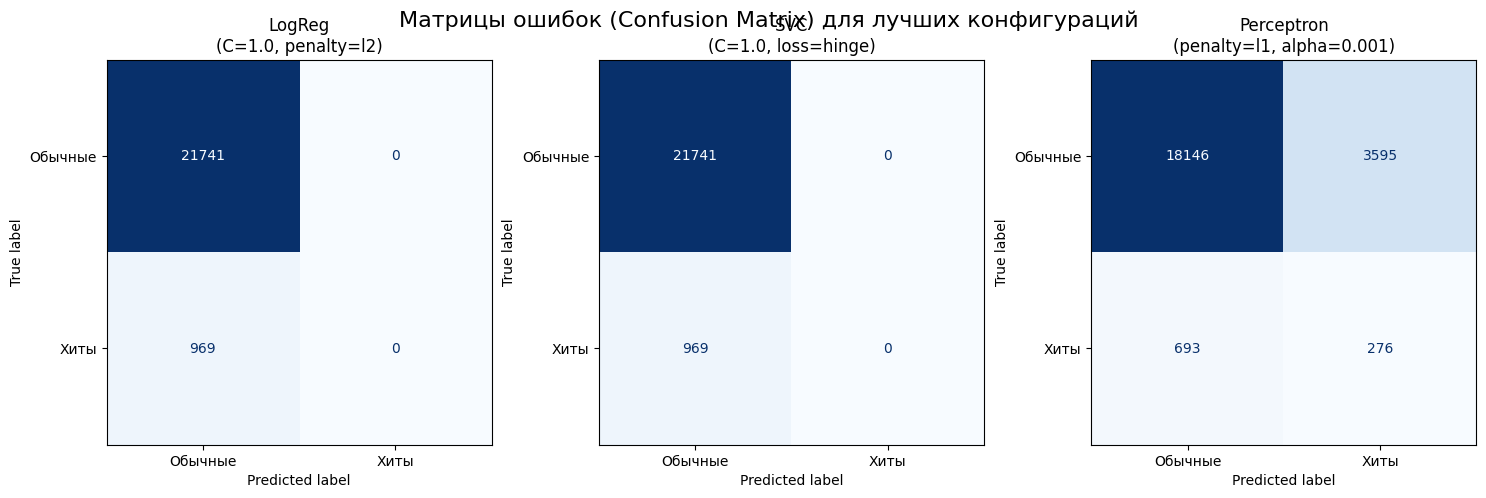

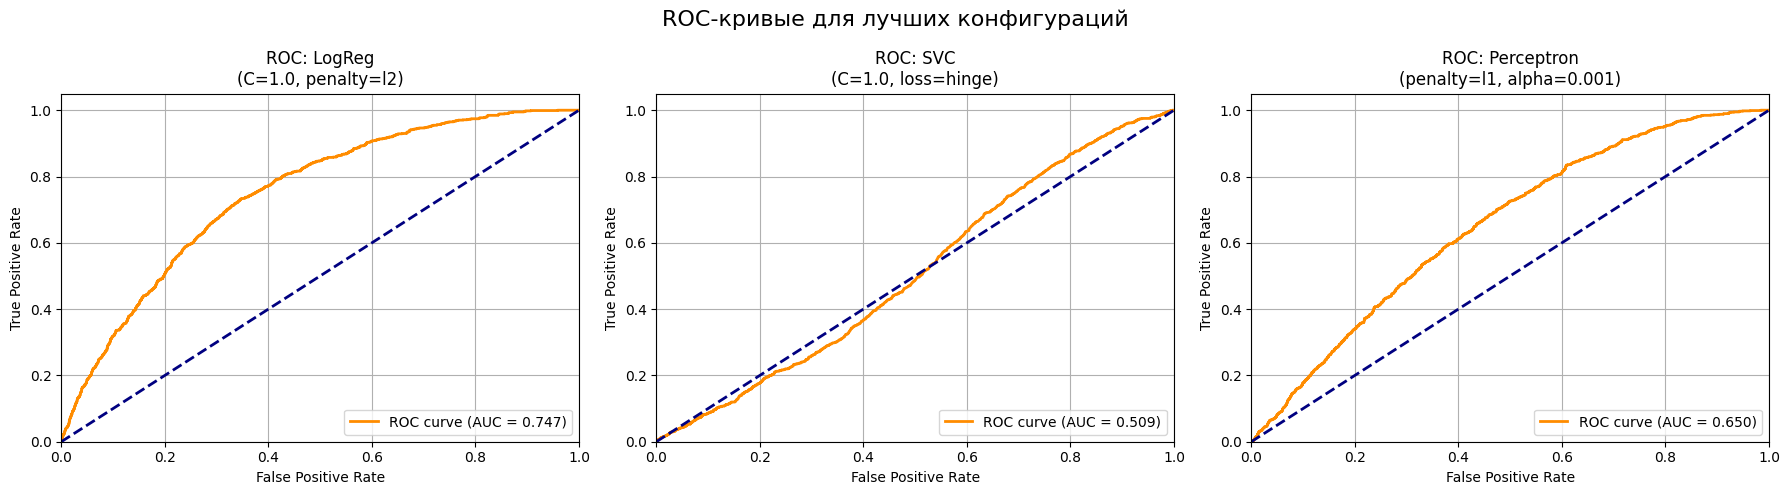

In [2]:
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Задание 1.1: Обучение моделей с варьированием параметров ---

# Список для хранения результатов (Задание 1.2, пункт 4)
results =[]
# Словари для сохранения лучших моделей по F1-мере для каждого алгоритма
best_models = {'LogReg': None, 'SVC': None, 'Perceptron': None}
best_f1 = {'LogReg': -1, 'SVC': -1, 'Perceptron': -1}

# 1. Логистическая регрессия
print("Обучение LogisticRegression...")
# solver='saga' нужен для penalty=None
logreg_params = [
    {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs', 'name': 'C=1.0, penalty=l2'},
    {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs', 'name': 'C=0.1, penalty=l2'},
    {'C': 1.0, 'penalty': None, 'solver': 'saga', 'name': 'C=1.0, penalty=None'},
    {'C': 0.1, 'penalty': None, 'solver': 'saga', 'name': 'C=0.1, penalty=None'}
]
for params in logreg_params:
    model = LogisticRegression(C=params['C'], penalty=params['penalty'], solver=params['solver'], max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.decision_function(X_test)
    
    f1 = f1_score(y_test, y_pred, zero_division=0)
    results.append({
        'Алгоритм': 'LogReg', 'Конфигурация': params['name'],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1,
        'AUC-ROC': roc_auc_score(y_test, y_score) # ДОБАВЛЕНО
    })
    if f1 > best_f1['LogReg']:
        best_f1['LogReg'] = f1; best_models['LogReg'] = {'model': model, 'name': params['name']}


# 2. LinearSVC
print("Обучение LinearSVC...")
for c in[1.0, 0.1]:
    for loss in ['hinge', 'squared_hinge']:
        config_name = f"C={c}, loss={loss}"
        # dual=True обязательно для loss='hinge'
        model = LinearSVC(C=c, loss=loss, max_iter=10000, dual=True, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        f1 = f1_score(y_test, y_pred, zero_division=0)
        results.append({
            'Алгоритм': 'SVC', 'Конфигурация': config_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred),
            'F1-score': f1,
            'AUC-ROC': roc_auc_score(y_test, model.decision_function(X_test))
        })
        if f1 > best_f1['SVC']:
            best_f1['SVC'] = f1
            best_models['SVC'] = {'model': model, 'name': config_name}

# 3. Perceptron
print("Обучение Perceptron...")
for pen in[None, 'l2', 'l1']:
    for alpha in[0.0001, 0.001]:
        config_name = f"penalty={pen}, alpha={alpha}"
        model = Perceptron(penalty=pen, alpha=alpha, max_iter=1000, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        f1 = f1_score(y_test, y_pred, zero_division=0)
        results.append({
            'Алгоритм': 'Perceptron', 'Конфигурация': config_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred),
            'F1-score': f1,
            'AUC-ROC': roc_auc_score(y_test, model.decision_function(X_test))
        })
        if f1 > best_f1['Perceptron']:
            best_f1['Perceptron'] = f1
            best_models['Perceptron'] = {'model': model, 'name': config_name}

# --- Задание 1.2: Вывод итоговой таблицы ---
results_df = pd.DataFrame(results)
print("\nИтоговая таблица метрик:")
display(results_df)

# --- Задание 1.2: ROC-кривые и Матрицы ошибок для ЛУЧШИХ моделей ---
fig, axes_cm = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Матрицы ошибок (Confusion Matrix) для лучших конфигураций', fontsize=16)

fig_roc, axes_roc = plt.subplots(1, 3, figsize=(18, 5))
fig_roc.suptitle('ROC-кривые для лучших конфигураций', fontsize=16)

for i, algo in enumerate(['LogReg', 'SVC', 'Perceptron']):
    best = best_models[algo]
    model = best['model']
    
    # Предсказания классов
    y_pred = model.predict(X_test)
    
    # 1. Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Обычные', 'Хиты'])
    disp.plot(ax=axes_cm[i], cmap='Blues', colorbar=False)
    axes_cm[i].set_title(f"{algo}\n({best['name']})")
    
    # 2. ROC-кривая и AUC
    # SVC и Perceptron не имеют predict_proba, поэтому используем decision_function
    y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    
    axes_roc[i].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
    axes_roc[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes_roc[i].set_xlim([0.0, 1.0])
    axes_roc[i].set_ylim([0.0, 1.05])
    axes_roc[i].set_xlabel('False Positive Rate')
    axes_roc[i].set_ylabel('True Positive Rate')
    axes_roc[i].set_title(f"ROC: {algo}\n({best['name']})")
    axes_roc[i].legend(loc="lower right")
    axes_roc[i].grid(True)

plt.tight_layout()
plt.show()

Эксперимент с class_weight='balanced'...


C:\Users\Danya\Desktop\MAD\UNI_MAD\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Результаты с class_weight='balanced':


,Алгоритм,Конфигурация,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,LogReg (balanced),"C=1.0, balanced",0.659445,0.085630,0.721362,0.153088,0.745773
1,LogReg (balanced),"C=0.1, balanced",0.659621,0.085672,0.721362,0.153155,0.745782
2,LinearSVC (balanced),"C=1.0, balanced",0.654954,0.084473,0.720330,0.151213,0.743716
3,LinearSVC (balanced),"C=0.1, balanced",0.655350,0.084565,0.720330,0.151361,0.743841


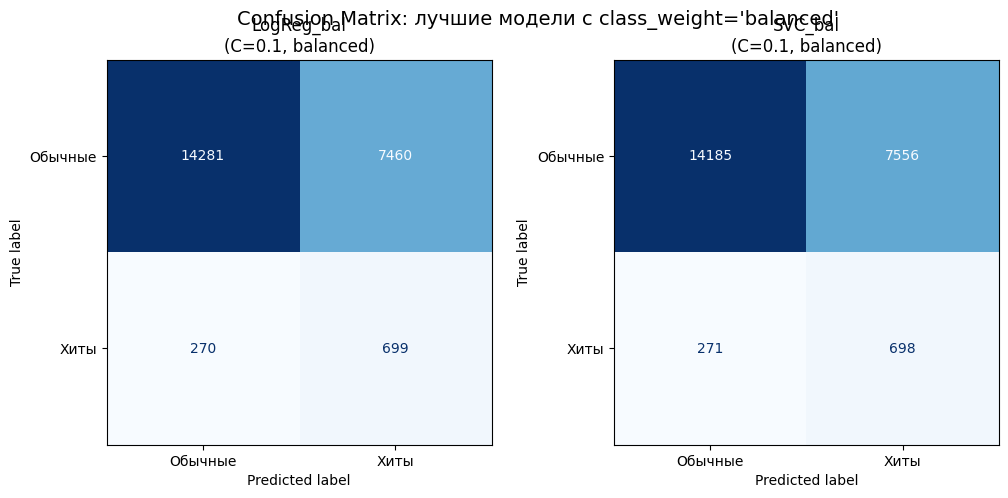

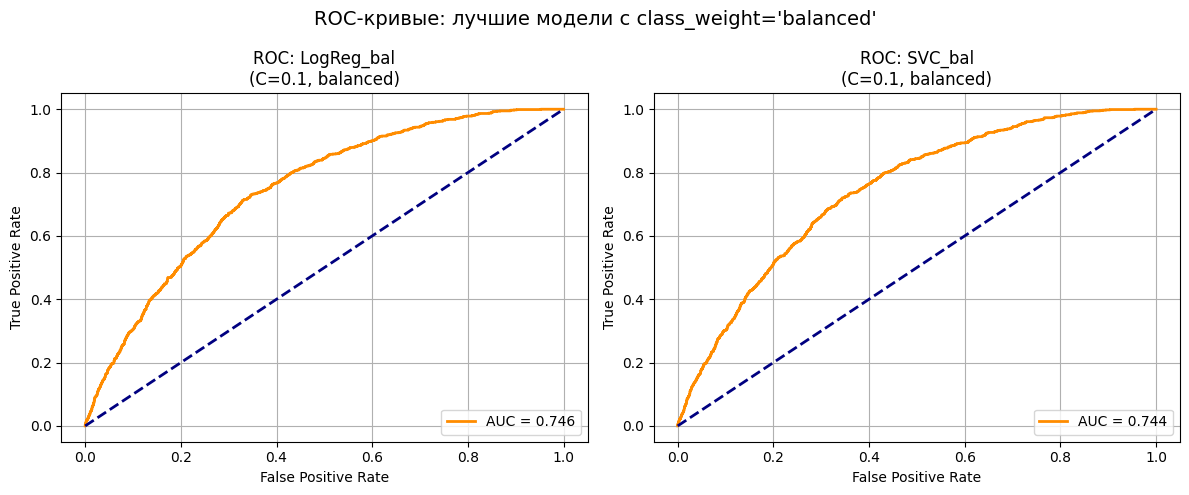

In [3]:
# --- Дополнительный эксперимент: class_weight='balanced' ---
print("Эксперимент с class_weight='balanced'...")

balanced_results = []
balanced_models = {}

# 1. LogisticRegression + balanced
for c in [1.0, 0.1]:
    config_name = f"C={c}, balanced"
    model = LogisticRegression(C=c, class_weight='balanced',
                               solver='lbfgs', max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.decision_function(X_test)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    balanced_results.append({
        'Алгоритм': 'LogReg (balanced)', 'Конфигурация': config_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1,
        'AUC-ROC': roc_auc_score(y_test, y_score)
    })
    if 'LogReg_bal' not in balanced_models or f1 > balanced_models['LogReg_bal']['f1']:
        balanced_models['LogReg_bal'] = {'model': model, 'name': config_name, 'f1': f1}

# 2. LinearSVC + balanced
for c in [1.0, 0.1]:
    config_name = f"C={c}, balanced"
    model = LinearSVC(C=c, loss='squared_hinge', class_weight='balanced',
                      max_iter=10000, dual=True, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    balanced_results.append({
        'Алгоритм': 'LinearSVC (balanced)', 'Конфигурация': config_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1,
        'AUC-ROC': roc_auc_score(y_test, model.decision_function(X_test))
    })
    if 'SVC_bal' not in balanced_models or f1 > balanced_models['SVC_bal']['f1']:
        balanced_models['SVC_bal'] = {'model': model, 'name': config_name, 'f1': f1}

balanced_df = pd.DataFrame(balanced_results)
print("\nРезультаты с class_weight='balanced':")
display(balanced_df)

# Матрицы ошибок и ROC для лучших balanced-моделей
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrix: лучшие модели с class_weight='balanced'", fontsize=14)
fig_roc, axes_roc = plt.subplots(1, 2, figsize=(12, 5))
fig_roc.suptitle("ROC-кривые: лучшие модели с class_weight='balanced'", fontsize=14)

for i, key in enumerate(['LogReg_bal', 'SVC_bal']):
    best = balanced_models[key]
    model = best['model']
    y_pred = model.predict(X_test)
    y_score = model.decision_function(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Обычные', 'Хиты'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"{key}\n({best['name']})")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    axes_roc[i].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.3f}')
    axes_roc[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes_roc[i].set_xlabel('False Positive Rate')
    axes_roc[i].set_ylabel('True Positive Rate')
    axes_roc[i].set_title(f"ROC: {key}\n({best['name']})")
    axes_roc[i].legend(loc="lower right")
    axes_roc[i].grid(True)

plt.tight_layout()
plt.show()

Задание 1.3: Анализ результатов

1. Лучшие конфигурации моделей:
LogReg и SVC: Все конфигурации показали F1 = 0. Модели полностью выродились из-за сильного дисбаланса классов (4.27% хитов) и предсказывают исключительно мажоритарный класс 0 («Обычные»).
Perceptron: Лучшая конфигурация — penalty=l1, alpha=0.001 (F1 = 0.114). L1-регуляризация выполняет отбор признаков и заставляет модель опираться только на самые важные характеристики, что помогло ей не скатиться в константное предсказание и выявить часть миноритарного класса.

2. Сравнение лучших конфигураций (F1 vs AUC-ROC):
По F1-мере: Лидер — Perceptron (0.114), так как это единственная модель, выдавшая значимые положительные предсказания. LogReg и SVC провалили задачу (0.000).
По AUC-ROC: Лидер — Логистическая регрессия (0.7475). Примечательно, что конфигурации LinearSVC с loss=squared_hinge показали почти идентичный результат (AUC ≈ 0.744), тогда как loss=hinge деградировал почти до случайного уровня (AUC ≈ 0.499–0.509). Это объясняется математикой: squared_hinge оптимизирует «мягкие» оценки, которые дают информативный decision_function; hinge при сильном дисбалансе вырождается в константный сдвиг. Perceptron занял промежуточное место (AUC = 0.650–0.693 в зависимости от конфигурации). Несмотря на нулевой F1 логрегрессии (по стандартному порогу 0.5 все треки ушли в класс 0), алгоритм выдаёт адекватные вероятности и лучше всех ранжирует классы.

3. Анализ ошибок (FP vs FN) и метрики:
LogReg и SVC: Совершают исключительно ошибки False Negative (FN). Они пропустили абсолютно все хиты (969 FN, 0 TP, 0 FP). Итог закономерен: Precision = 0 и Recall = 0.
Perceptron: Ошибается преимущественно в виде False Positive (FP). Модель слишком агрессивно ищет хиты (3595 FP против 693 FN). Из-за огромного числа ложных срабатываний Precision крайне низкая (0.071), но за счёт того, что модель всё-таки нашла часть реальных хитов (276 TP), метрика Recall значительно выше (0.285).


ДОП:
Обе модели нашли 698–699 реальных хитов из 969 (Recall ≈ 0.72), заплатив за это высокой ценой ложных срабатываний (7460–7556 FP). Низкий Precision (0.086) объясняется именно этим: модель «смотрит широко» и не пропускает хиты, но вместе с ними захватывает много обычных треков.


In [4]:
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# --- Задание 2.1: Нелинейная SVM с ядрами ---

print("Делаем сэмпл 15000 строк из обучающей выборки, чтобы ноутбук не завис намертво...")
# stratify=y_train гарантирует, что в эти 15000 строк попадет правильный процент хитов
X_train_sub, y_train_sub = resample(X_train, y_train, n_samples=15000, random_state=42, stratify=y_train)

# Список моделей для обучения
models_to_train =[
    {'name': "SVM (RBF kernel)", 'model': SVC(kernel='rbf', random_state=42)},
    {'name': "SVM (Poly kernel, deg=2)", 'model': SVC(kernel='poly', degree=2, random_state=42)},
    {'name': "SVM (Poly kernel, deg=3)", 'model': SVC(kernel='poly', degree=3, random_state=42)},
    {'name': "SVM (Poly kernel, deg=4)", 'model': SVC(kernel='poly', degree=4, random_state=42)}
]

# Сюда соберем результаты
results_nonlinear =[]

print("Начинаем обучение нелинейных моделей SVC...")

for item in models_to_train:
    model_name = item['name']
    model = item['model']
    
    print(f"Обучаем {model_name}...")
    
    # Обучаем на сэмпле
    model.fit(X_train_sub, y_train_sub)
    
    # Предсказываем на ПОЛНОЙ тестовой выборке
    y_pred = model.predict(X_test)
    
    # Считаем метрики
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Вспоминаем, что SVC (как и LinearSVC) не имеет predict_proba, используем decision_function для AUC
    auc = roc_auc_score(y_test, model.decision_function(X_test))
    
    results_nonlinear.append({
        'Алгоритм': model_name,
        'F1-score': f1,
        'AUC-ROC': auc,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0)
    })

# --- Сравнение с лучшей линейной моделью (ИСПРАВЛЕНО) ---
# Находим лучшую LogReg по AUC из первой таблицы программно
best_linear_auc = results_df[results_df['Алгоритм'] == 'LogReg']['AUC-ROC'].max()
best_linear_row = results_df.iloc[results_df[results_df['Алгоритм'] == 'LogReg']['AUC-ROC'].idxmax()]

# Добавляем в таблицу результатов
results_nonlinear.append({
    'Алгоритм': 'LogReg (из Этапа 1)',
    'F1-score': best_linear_row['F1-score'],
    'AUC-ROC': best_linear_auc,
    'Accuracy': best_linear_row['Accuracy'],
    'Precision': best_linear_row['Precision'],
    'Recall': best_linear_row['Recall']
})

results_nonlinear_df = pd.DataFrame(results_nonlinear)
print("\n--- Результаты нелинейных моделей в сравнении с лучшей линейной ---")
print("ВАЖНО: Линейные модели обучались на полных данных (~90k), нелинейные - на сэмпле (15k).") # ДОБАВЛЕНА ОГОВОРКА
display(results_nonlinear_df)

Делаем сэмпл 15000 строк из обучающей выборки, чтобы ноутбук не завис намертво...
Начинаем обучение нелинейных моделей SVC...
Обучаем SVM (RBF kernel)...
Обучаем SVM (Poly kernel, deg=2)...
Обучаем SVM (Poly kernel, deg=3)...
Обучаем SVM (Poly kernel, deg=4)...

--- Результаты нелинейных моделей в сравнении с лучшей линейной ---
ВАЖНО: Линейные модели обучались на полных данных (~90k), нелинейные - на сэмпле (15k).


,Алгоритм,F1-score,AUC-ROC,Accuracy,Precision,Recall
0,SVM (RBF kernel),0.000000,0.715521,0.957332,0.00,0.000000
1,"SVM (Poly kernel, deg=2)",0.000000,0.648461,0.957332,0.00,0.000000
2,"SVM (Poly kernel, deg=3)",0.000000,0.710793,0.956935,0.00,0.000000
3,"SVM (Poly kernel, deg=4)",0.006116,0.719344,0.957067,0.25,0.003096
4,LogReg (из Этапа 1),0.000000,0.747502,0.957332,0.00,0.000000


Модели SVM с ядрами rbf, poly (степени 2 и 3) показали F1-score = 0, предсказав для всех объектов тестовой выборки мажоритарный класс 0 («Обычные треки»). Единственным исключением стала модель с полиномиальным ядром степени 4, которая сумела выявить ничтожную долю хитов (F1 = 0.006, Precision = 0.25, Recall = 0.003) — первый признак того, что более сложная граница начинает работать.

Вопреки ожиданиям, лучшей нелинейной моделью без оптимизации стала SVM с полиномиальным ядром степени 4 — она единственная показала ненулевой F1 (0.006) и наивысший AUC-ROC среди нелинейных (0.719). RBF-ядро заняло второе место (AUC = 0.715, F1 = 0), модели с poly deg=2 и deg=3 оказались слабее.
Ни одна из нелинейных моделей не превзошла лучшую линейную модель — Логистическую регрессию (AUC = 0.747).

Итог: При стандартных гиперпараметрах нелинейность не решила проблему сильного дисбаланса классов. Тем не менее, poly deg=4 дал первый ненулевой F1, что указывает на потенциал более сложных границ — это мотивирует дальнейший подбор гиперпараметров в заданиях 2.2–2.3.

In [5]:
from sklearn.model_selection import GridSearchCV

# --- Задание 2.2: Исследование гиперпараметров с помощью GridSearchCV ---

print("Запускаем GridSearchCV для SVC с RBF-ядром. Это может занять несколько минут...")

# 1. Создаем "сетку" параметров для перебора
param_grid_rbf = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto']
}

# 2. Инициализируем GridSearchCV
# Мы ищем лучшую модель по F1-мере ('f1')
# cv=5 означает 5-кратную кросс-валидацию
# n_jobs=-1 задействует все ядра процессора для ускорения
grid_search_rbf = GridSearchCV(
    estimator=SVC(kernel='rbf', random_state=42),
    param_grid=param_grid_rbf,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# 3. Обучаем на том же сэмпле из 15000 строк!
grid_search_rbf.fit(X_train_sub, y_train_sub)

# 4. Выводим лучшие параметры и лучшую оценку
print(f"\nЛучшие параметры для RBF-ядра: {grid_search_rbf.best_params_}")
print(f"Лучшая F1-мера на кросс-валидации: {grid_search_rbf.best_score_:.4f}")

# 5. Оцениваем ЛУЧШУЮ найденную модель на ТЕСТОВОЙ выборке
best_rbf_model = grid_search_rbf.best_estimator_
y_pred_best_rbf = best_rbf_model.predict(X_test)

f1_best_rbf = f1_score(y_test, y_pred_best_rbf)
print(f"\nF1-мера лучшей RBF-модели на тестовой выборке: {f1_best_rbf:.4f}")

# Сравнение с RBF по умолчанию
f1_default_rbf = results_nonlinear_df.loc[0, 'F1-score']
print(f"F1-мера RBF-модели по умолчанию: {f1_default_rbf:.4f}")

Запускаем GridSearchCV для SVC с RBF-ядром. Это может занять несколько минут...

Лучшие параметры для RBF-ядра: {'C': 100, 'gamma': 1}
Лучшая F1-мера на кросс-валидации: 0.3153

F1-мера лучшей RBF-модели на тестовой выборке: 0.1583
F1-мера RBF-модели по умолчанию: 0.0000


Был выполнен автоматический подбор гиперпараметров C и gamma для модели SVC с RBF-ядром с помощью GridSearchCV. В качестве метрики оптимизации была выбрана f1 как наиболее релевантная для задачи с дисбалансом классов.

Лучшей конфигурацией признана {'C': 100, 'gamma': 1}. На 5-кратной кросс-валидации эта модель показала среднюю F1-меру 0.3153. Оценка на отложенной тестовой выборке дала F1 = 0.1583.

Итог: Автоматическая оптимизация гиперпараметров кардинально улучшила качество модели. В отличие от неоптимизированной RBF-модели (F1 = 0.0), найденная конфигурация способна выявлять миноритарный класс («Хиты»), хотя и с невысокой точностью. Разрыв между CV-оценкой (0.315) и тестом (0.158) указывает на некоторое переобучение на обучающем сэмпле.

In [6]:
# --- Задание 2.3: GridSearchCV для Полиномиального ядра ---

print("\nЗапускаем GridSearchCV для SVC с Poly-ядром...")

# 1. Создаем сетку параметров для полиномиального ядра
param_grid_poly = {
    'C': [0.1, 1, 10],
    'degree': [2, 3, 4],
    'coef0': [0, 1]
}

# 2. Инициализируем GridSearchCV
grid_search_poly = GridSearchCV(
    estimator=SVC(kernel='poly', random_state=42),
    param_grid=param_grid_poly,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# 3. Обучаем на сэмпле
grid_search_poly.fit(X_train_sub, y_train_sub)

# 4. Выводим результаты
print(f"\nЛучшие параметры для Poly-ядра: {grid_search_poly.best_params_}")
print(f"Лучшая F1-мера на кросс-валидации: {grid_search_poly.best_score_:.4f}")

# 5. Оцениваем на тесте и сравниваем
best_poly_model = grid_search_poly.best_estimator_
y_pred_best_poly = best_poly_model.predict(X_test)

f1_best_poly = f1_score(y_test, y_pred_best_poly)
print(f"\nF1-мера лучшей Poly-модели на тестовой выборке: {f1_best_poly:.4f}")
print(f"F1-мера лучшей RBF-модели (из прошлого шага): {f1_best_rbf:.4f}")


Запускаем GridSearchCV для SVC с Poly-ядром...

Лучшие параметры для Poly-ядра: {'C': 10, 'coef0': 1, 'degree': 4}
Лучшая F1-мера на кросс-валидации: 0.1523

F1-мера лучшей Poly-модели на тестовой выборке: 0.0955
F1-мера лучшей RBF-модели (из прошлого шага): 0.1583


Был выполнен подбор гиперпараметров для полиномиального ядра. Лучшей конфигурацией признана {'C': 10, 'coef0': 1, 'degree': 4}. На кросс-валидации — F1 = 0.1523, на тестовой выборке — F1 = 0.0955.

Какое ядро показало себя лучше?
Итоговый результат неоднозначный. Без оптимизации poly deg=4 опережал RBF по обеим метрикам (F1: 0.006 vs 0.000, AUC: 0.719 vs 0.715). Однако после GridSearchCV ситуация кардинально изменилась: RBF взял реванш с большим отрывом (F1 = 0.158 против 0.096 у poly). Это говорит о том, что RBF-ядро значительно более чувствительно к выбору гиперпараметров — при дефолтных значениях оно проигрывает, но при правильной настройке раскрывает свой потенциал и лучше аппроксимирует реальную границу между «хитами» и «обычными треками».

Как меняется качество при увеличении степени полинома?
GridSearchCV выбрал максимальную из предложенных степеней (degree=4), что говорит о том, что граница требует сложной кривой. Примечательно, что ещё в Задании 2.1 именно deg=4 единственный дал ненулевой F1, тогда как степени 2 и 3 — нет. Тем не менее, даже полином 4-й степени не смог сравниться с оптимизированным RBF-ядром, что указывает на начало переобучения: модель становится слишком сложной и начинает подстраиваться под шум в обучающей выборке, теряя обобщающую способность на новых данных.

## Общие выводы по лабораторной работе №5

Линейные методы: Логистическая регрессия и LinearSVC оказались неспособны справиться с задачей классификации хитов из-за сильного дисбаланса классов (4.27%), показав F1 = 0. Исключение составляет Perceptron с L1-регуляризацией (F1 = 0.114). По метрике AUC-ROC лидирует Логистическая регрессия (0.747), при этом LinearSVC с loss=squared_hinge показал сопоставимый результат (0.744).

Нелинейные методы без оптимизации: Нелинейные SVM со стандартными параметрами в целом также не решили задачу. Единственным исключением стала poly deg=4 с минимальным ненулевым F1 (0.006), что указало на направление для дальнейшей оптимизации.

Оптимизация гиперпараметров: Ключевым фактором успеха стал GridSearchCV. Оптимизация по F1-мере позволила обеим нелинейным моделям выйти из нуля. При этом RBF оказался более отзывчивым к подбору параметров.

Лучшая модель: Абсолютным победителем по F1-мере стала SVM с ядром RBF и оптимизированными параметрами {'C': 100, 'gamma': 1}, показавшая на тесте F1 = 0.1583. Несмотря на это, абсолютные значения метрик остаются невысокими — фундаментальной проблемой остаётся дисбаланс классов, для решения которого следует применять техники oversampling (SMOTE) или взвешивание классов (class_weight='balanced').